In [1]:
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt 


In [2]:
(x_train,y_train),(x_test,y_test) = fashion_mnist.load_data()

In [15]:
print((x_train[0].shape))
print(x_train[0].min())

(28, 28)
0.0


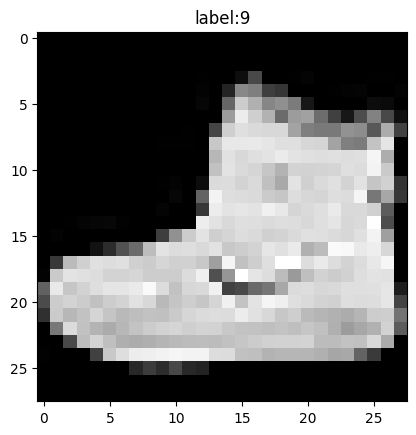

In [4]:
plt.imshow(x_train[0],cmap='grey')
plt.title(f'label:{y_train[0]}')
plt.show()

In [5]:
x_train = x_train/255
x_test = x_test/255

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten

In [7]:
model = Sequential(
    [
        Flatten(input_shape = (28,28)),
        Dense(128,activation='relu'),
        Dense(64,activation='relu'),
        Dense(10,activation='softmax')
    ]
)

/Users/anuragpanchal/Documents/DeepLearning/DeepLearning/venv/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [9]:
history = model.fit(x_train,y_train,epochs=10,validation_data=(x_test,y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 890us/step - accuracy: 0.8242 - loss: 0.4922 - val_accuracy: 0.8476 - val_loss: 0.4218
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 786us/step - accuracy: 0.8665 - loss: 0.3673 - val_accuracy: 0.8555 - val_loss: 0.3976
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 832us/step - accuracy: 0.8776 - loss: 0.3334 - val_accuracy: 0.8641 - val_loss: 0.3762
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - accuracy: 0.8854 - loss: 0.3107 - val_accuracy: 0.8633 - val_loss: 0.3815
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 818us/step - accuracy: 0.8914 - loss: 0.2934 - val_accuracy: 0.8776 - val_loss: 0.3425
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 816us/step - accuracy: 0.8940 - loss: 0.2797 - val_accuracy: 0.8672 - val_loss: 0.3525
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 884us/step - accuracy: 0.9003 - loss: 0.2685 - val_accuracy: 0.8756 - val_loss: 0.3414
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 898us/step - accuracy: 0.9023 -

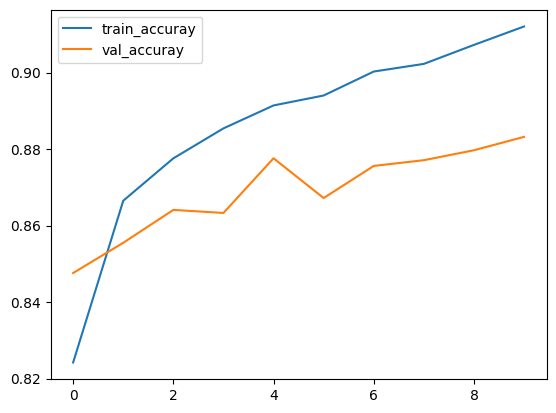

In [10]:
plt.plot(history.history['accuracy'],label='train_accuray')
plt.plot(history.history['val_accuracy'],label='val_accuray')
plt.legend()
plt.show()


In [11]:
loss,acc = model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 394us/step - accuracy: 0.8832 - loss: 0.3308


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 331us/step


Text(0.5, 1.0, 'Actual:2|predicted:2')

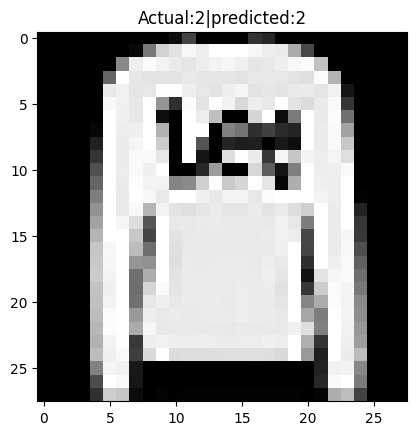

In [12]:
import numpy as np 
pred = model.predict(x_test)
index = 1
plt.imshow(x_test[index],cmap='grey')
plt.title(f"Actual:{y_test[index]}|predicted:{np.argmax(pred[index])}")